In [ ]:
!pip install sdv==1.17.4 imbalanced-learn lightgbm xgboost catboost --quiet
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.0/155.0 kB 2.3 MB/s eta 0:00:00
Done.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

print("All libraries imported.")

All libraries imported.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

DATA_DIR   = f"{PROJECT_DIR}/data"
MODEL_DIR  = f"{PROJECT_DIR}/models"
RESULT_DIR = f"{PROJECT_DIR}/results"
FIGURE_DIR = f"{PROJECT_DIR}/figures"

for folder in [DATA_DIR, MODEL_DIR, RESULT_DIR, FIGURE_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Directories ready.")

Directories ready.


In [ ]:
TARGET = "dropout_label"

df = pd.read_csv(f"{DATA_DIR}/engineered_data.csv")

print("Shape:", df.shape)
print("\nClass distribution:")
print(df[TARGET].value_counts())
print(f"\nDropout rate: {df[TARGET].mean():.1%}")

df.head()

Shape: (1000, 39)

Class distribution:
dropout_label
0    908
1     92
Name: count, dtype: int64

Dropout rate: 9.2%


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,1,0,1,1,1,10.0,0,0,85.0,82.0,...,3.0,0,3,3,4,5,2,5.0,0,0
1,1,0,1,1,1,11.0,0,0,87.0,79.0,...,3.0,0,3,3,4,4,3,2.0,1,0
2,1,0,1,1,1,10.0,0,0,70.0,79.0,...,1.0,2,3,0,4,5,2,5.0,1,0
3,1,0,1,1,0,12.0,0,0,80.0,83.0,...,4.0,0,4,3,2,3,2,4.0,1,0
4,1,0,1,1,0,10.0,0,0,77.0,80.0,...,3.0,0,3,3,2,5,2,4.0,0,0


In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", X.shape[1])
print("Samples: ", X.shape[0])

Features: 38
Samples:  1000


In [ ]:
# CRITICAL: Split FIRST. Test set is never touched again.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Train set:  {X_train.shape[0]} rows")
print(f"Test set:   {X_test.shape[0]} rows")
print(f"\nTrain dropout count: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test  dropout count: {y_test.sum()}  ({y_test.mean():.1%})")

Train set:  800 rows
Test set:   200 rows

Train dropout count: 74 (9.2%)
Test  dropout count: 18  (9.0%)


In [ ]:
# Single reusable function used across ALL experiments
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model and return evaluation metrics."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    pred  = model.predict(X_te)
    prob  = model.predict_proba(X_te)[:, 1]

    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_te, pred),              4),
        "Precision": round(precision_score(y_te, pred,
                           zero_division=0),                         4),
        "Recall":    round(recall_score(y_te, pred,
                           zero_division=0),                         4),
        "F1":        round(f1_score(y_te, pred, average="macro"),   4),
        "ROC_AUC":   round(roc_auc_score(y_te, prob),               4),
        "PR_AUC":    round(average_precision_score(y_te, prob),     4),
        "Time_s":    round(elapsed, 2),
    }

print("Evaluation function defined.")

Evaluation function defined.


In [ ]:
# Compute class weights for models that support it
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
cw = dict(zip(classes, weights))
print("Class weights:", cw)

# Positive class ratio for XGBoost
pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

def get_models():
    """Return fresh instances of all six models."""
    return {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42),

        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced", max_depth=6, random_state=42),

        "Random Forest": RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=42, n_jobs=-1),

        "XGBoost": XGBClassifier(
            n_estimators=200, scale_pos_weight=pos_ratio,
            learning_rate=0.05, max_depth=6,
            random_state=42, verbosity=0, eval_metric="logloss"),

        "LightGBM": LGBMClassifier(
            n_estimators=200, is_unbalance=True,
            learning_rate=0.05, num_leaves=63,
            random_state=42, verbosity=-1, n_jobs=-1),

        "CatBoost": CatBoostClassifier(
            iterations=200, class_weights=cw,
            learning_rate=0.05, depth=6,
            random_state=42, verbose=0),
    }

print("Models defined.")

Class weights: {np.int64(0): np.float64(0.5509641873278237), np.int64(1): np.float64(5.405405405405405)}
Models defined.


In [ ]:
print("=" * 55)
print("EXPERIMENT A — ORIGINAL DATA (No Augmentation)")
print("=" * 55)

original_results = []
models_A = get_models()

for name, model in models_A.items():
    result = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    original_results.append(result)
    print(f"  {name:<22} F1={result['F1']:.4f}  "
          f"AUC={result['ROC_AUC']:.4f}  "
          f"Recall={result['Recall']:.4f}")

original_df = pd.DataFrame(original_results)
original_df.insert(0, "Experiment", "Original")
original_df.to_csv(f"{RESULT_DIR}/original_results.csv", index=False)

print("\nExperiment A complete. Saved: original_results.csv")
original_df

EXPERIMENT A — ORIGINAL DATA (No Augmentation)
  Logistic Regression    F1=0.9290  AUC=0.9710  Recall=0.9444
  Decision Tree          F1=0.9843  AUC=0.9722  Recall=0.9444
  Random Forest          F1=0.9843  AUC=0.9983  Recall=0.9444
  XGBoost                F1=0.9843  AUC=0.9963  Recall=0.9444
  LightGBM               F1=0.9843  AUC=0.9954  Recall=0.9444
  CatBoost               F1=0.9843  AUC=0.9988  Recall=0.9444

Experiment A complete. Saved: original_results.csv


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Time_s
0,Original,Logistic Regression,0.975,0.8095,0.9444,0.9290,0.9710,0.9471,1.00
1,Original,Decision Tree,0.995,1.0000,0.9444,0.9843,0.9722,0.9494,0.03
2,Original,Random Forest,0.995,1.0000,0.9444,0.9843,0.9983,0.9861,0.84
3,Original,XGBoost,0.995,1.0000,0.9444,0.9843,0.9963,0.9778,1.22
4,Original,LightGBM,0.995,1.0000,0.9444,0.9843,0.9954,0.9747,0.58
5,Original,CatBoost,0.995,1.0000,0.9444,0.9843,0.9988,0.9899,1.18


In [ ]:
print("=" * 55)
print("EXPERIMENT B — SMOTE Oversampling")
print("=" * 55)

# Apply SMOTE to training set ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {len(X_train)} rows | "
      f"Dropout: {y_train.sum()} ({y_train.mean():.1%})")
print(f"After SMOTE:  {len(X_train_smote)} rows | "
      f"Dropout: {y_train_smote.sum()} "
      f"({y_train_smote.mean():.1%})")

smote_results = []
models_B = get_models()

for name, model in models_B.items():
    result = evaluate_model(name, model,
                             X_train_smote, y_train_smote,
                             X_test, y_test)
    smote_results.append(result)
    print(f"  {name:<22} F1={result['F1']:.4f}  "
          f"AUC={result['ROC_AUC']:.4f}  "
          f"Recall={result['Recall']:.4f}")

smote_df = pd.DataFrame(smote_results)
smote_df.insert(0, "Experiment", "SMOTE")
smote_df.to_csv(f"{RESULT_DIR}/smote_results.csv", index=False)

print("\nExperiment B complete. Saved: smote_results.csv")
smote_df

EXPERIMENT B — SMOTE Oversampling
Before SMOTE: 800 rows | Dropout: 74 (9.2%)
After SMOTE:  1452 rows | Dropout: 726 (50.0%)
  Logistic Regression    F1=0.9695  AUC=0.9701  Recall=0.9444
  Decision Tree          F1=0.9553  AUC=0.9692  Recall=0.9444
  Random Forest          F1=0.9843  AUC=0.9974  Recall=0.9444
  XGBoost                F1=0.9843  AUC=0.9979  Recall=0.9444
  LightGBM               F1=0.9843  AUC=0.9908  Recall=0.9444
  CatBoost               F1=0.9695  AUC=0.9951  Recall=0.9444

Experiment B complete. Saved: smote_results.csv


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Time_s
0,SMOTE,Logistic Regression,0.990,0.9444,0.9444,0.9695,0.9701,0.9531,1.81
1,SMOTE,Decision Tree,0.985,0.8947,0.9444,0.9553,0.9692,0.8970,0.06
2,SMOTE,Random Forest,0.995,1.0000,0.9444,0.9843,0.9974,0.9815,1.02
3,SMOTE,XGBoost,0.995,1.0000,0.9444,0.9843,0.9979,0.9844,0.50
4,SMOTE,LightGBM,0.995,1.0000,0.9444,0.9843,0.9908,0.9653,1.87
5,SMOTE,CatBoost,0.990,0.9444,0.9444,0.9695,0.9951,0.9739,1.82


In [ ]:
print("=" * 55)
print("EXPERIMENT C — CTGAN +250 Synthetic Records")
print("=" * 55)

# Work only with the training set
train_df = X_train.copy()
train_df[TARGET] = y_train.values

# Separate minority class (dropout = 1) from training set
dropout_train = train_df[train_df[TARGET] == 1].copy()
print(f"Real dropout records in training set: {len(dropout_train)}")

# Train CTGAN on dropout records only
print("\nTraining CTGAN on minority class...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(dropout_train)

ctgan = CTGANSynthesizer(metadata, epochs=300, verbose=False)
ctgan.fit(dropout_train)

# Generate 250 synthetic dropout records
print("Generating 250 synthetic dropout records...")
synthetic_250 = ctgan.sample(num_rows=250)
synthetic_250[TARGET] = 1   # ensure label is correct

# Combine with full training set
train_ctgan_250 = pd.concat([train_df, synthetic_250], ignore_index=True)

X_train_ctgan = train_ctgan_250.drop(columns=[TARGET])
y_train_ctgan = train_ctgan_250[TARGET]

print(f"\nCTGAN training set: {len(train_ctgan_250)} rows | "
      f"Dropout: {y_train_ctgan.sum()} "
      f"({y_train_ctgan.mean():.1%})")

# Save CTGAN model
ctgan.save(f"{MODEL_DIR}/ctgan_model.pkl")
print("CTGAN model saved.")

EXPERIMENT C — CTGAN +250 Synthetic Records
Real dropout records in training set: 74

Training CTGAN on minority class...
Generating 250 synthetic dropout records...

CTGAN training set: 1050 rows | Dropout: 324 (30.9%)
CTGAN model saved.


In [ ]:
ctgan_results = []
models_C = get_models()

for name, model in models_C.items():
    result = evaluate_model(name, model,
                             X_train_ctgan, y_train_ctgan,
                             X_test, y_test)
    ctgan_results.append(result)
    print(f"  {name:<22} F1={result['F1']:.4f}  "
          f"AUC={result['ROC_AUC']:.4f}  "
          f"Recall={result['Recall']:.4f}")

ctgan_df = pd.DataFrame(ctgan_results)
ctgan_df.insert(0, "Experiment", "CTGAN_250")
ctgan_df.to_csv(f"{RESULT_DIR}/ctgan_results.csv", index=False)

print("\nExperiment C complete. Saved: ctgan_results.csv")
ctgan_df

  Logistic Regression    F1=0.9167  AUC=0.9814  Recall=0.9444
  Decision Tree          F1=0.9321  AUC=0.9899  Recall=1.0000
  Random Forest          F1=0.9843  AUC=0.9956  Recall=0.9444
  XGBoost                F1=0.9843  AUC=0.9942  Recall=0.9444
  LightGBM               F1=0.9843  AUC=0.9933  Recall=0.9444
  CatBoost               F1=0.9843  AUC=0.9963  Recall=0.9444

Experiment C complete. Saved: ctgan_results.csv


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Time_s
0,CTGAN_250,Logistic Regression,0.970,0.7727,0.9444,0.9167,0.9814,0.9571,0.30
1,CTGAN_250,Decision Tree,0.975,0.7826,1.0000,0.9321,0.9899,0.8323,0.02
2,CTGAN_250,Random Forest,0.995,1.0000,0.9444,0.9843,0.9956,0.9739,0.59
3,CTGAN_250,XGBoost,0.995,1.0000,0.9444,0.9843,0.9942,0.9715,0.19
4,CTGAN_250,LightGBM,0.995,1.0000,0.9444,0.9843,0.9933,0.9694,0.38
5,CTGAN_250,CatBoost,0.995,1.0000,0.9444,0.9843,0.9963,0.9778,0.93


In [ ]:
print("=" * 55)
print("EXPERIMENT D — CTGAN +500 Synthetic Records")
print("=" * 55)

# Generate 500 synthetic dropout records using same CTGAN model
print("Generating 500 synthetic dropout records...")
synthetic_500 = ctgan.sample(num_rows=500)
synthetic_500[TARGET] = 1

train_ctgan_500 = pd.concat([train_df, synthetic_500], ignore_index=True)

X_train_ctgan500 = train_ctgan_500.drop(columns=[TARGET])
y_train_ctgan500 = train_ctgan_500[TARGET]

print(f"CTGAN-500 training set: {len(train_ctgan_500)} rows | "
      f"Dropout: {y_train_ctgan500.sum()} "
      f"({y_train_ctgan500.mean():.1%})")

ctgan500_results = []
models_D = get_models()

for name, model in models_D.items():
    result = evaluate_model(name, model,
                             X_train_ctgan500, y_train_ctgan500,
                             X_test, y_test)
    ctgan500_results.append(result)
    print(f"  {name:<22} F1={result['F1']:.4f}  "
          f"AUC={result['ROC_AUC']:.4f}  "
          f"Recall={result['Recall']:.4f}")

ctgan500_df = pd.DataFrame(ctgan500_results)
ctgan500_df.insert(0, "Experiment", "CTGAN_500")
ctgan500_df.to_csv(f"{RESULT_DIR}/ctgan500_results.csv", index=False)

print("\nExperiment D complete. Saved: ctgan500_results.csv")
ctgan500_df

EXPERIMENT D — CTGAN +500 Synthetic Records
Generating 500 synthetic dropout records...
CTGAN-500 training set: 1300 rows | Dropout: 574 (44.2%)
  Logistic Regression    F1=0.9418  AUC=0.9872  Recall=0.9444
  Decision Tree          F1=0.9695  AUC=0.9695  Recall=0.9444
  Random Forest          F1=0.9843  AUC=0.9916  Recall=0.9444
  XGBoost                F1=0.9843  AUC=0.9921  Recall=0.9444
  LightGBM               F1=0.9843  AUC=0.9963  Recall=0.9444
  CatBoost               F1=0.9290  AUC=0.9963  Recall=0.9444

Experiment D complete. Saved: ctgan500_results.csv


,Experiment,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Time_s
0,CTGAN_500,Logistic Regression,0.980,0.8500,0.9444,0.9418,0.9872,0.9611,0.39
1,CTGAN_500,Decision Tree,0.990,0.9444,0.9444,0.9695,0.9695,0.8970,0.02
2,CTGAN_500,Random Forest,0.995,1.0000,0.9444,0.9843,0.9916,0.9662,0.62
3,CTGAN_500,XGBoost,0.995,1.0000,0.9444,0.9843,0.9921,0.9672,0.22
4,CTGAN_500,LightGBM,0.995,1.0000,0.9444,0.9843,0.9963,0.9778,0.41
5,CTGAN_500,CatBoost,0.975,0.8095,0.9444,0.9290,0.9963,0.9778,0.70


In [ ]:
print("=" * 55)
print("TSTR VALIDATION — Synthetic Data Quality Check")
print("=" * 55)

from sklearn.ensemble import RandomForestClassifier as RFC

# Split real training data into ref train / ref test
X_real_tr, X_real_te, y_real_tr, y_real_te = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42)

# TRTR — train on real, test on real
rf_r = RFC(n_estimators=100, class_weight="balanced", random_state=42)
rf_r.fit(X_real_tr, y_real_tr)
trtr = roc_auc_score(y_real_te, rf_r.predict_proba(X_real_te)[:,1])

# TSTR — train on synthetic, test on real
# Use the combined training set from CTGAN +500 experiment, which contains both classes.
X_syn_tstr = X_train_ctgan500
y_syn_tstr = y_train_ctgan500

rf_s = RFC(n_estimators=100, class_weight="balanced", random_state=42)
rf_s.fit(X_syn_tstr, y_syn_tstr)
tstr = roc_auc_score(y_real_te, rf_s.predict_proba(X_real_te)[:,1])

gap = abs(trtr - tstr)

print(f"TRTR AUC (train real,  test real): {trtr:.4f}")
print(f"TSTR AUC (train synth, test real): {tstr:.4f}")
print(f"Gap:                               {gap:.4f}")
print()
if gap < 0.05:
    print("✓ PASS — synthetic data is representative (gap < 0.05)")
elif gap < 0.10:
    print("⚠ MARGINAL — gap between 0.05 and 0.10. Note as limitation.")
else:
    print("✗ FAIL — gap > 0.10. Increase CTGAN epochs and regenerate.")

tstr_summary = pd.DataFrame([{
    "TRTR_AUC": round(trtr, 4),
    "TSTR_AUC": round(tstr, 4),
    "Gap":      round(gap,  4),
    "Result":   "PASS" if gap < 0.05 else ("MARGINAL" if gap < 0.10 else "FAIL")
}])
tstr_summary.to_csv(f"{RESULT_DIR}/tstr_validation.csv", index=False)
print("Saved: tstr_validation.csv")

TSTR VALIDATION — Synthetic Data Quality Check
TRTR AUC (train real,  test real): 0.9982
TSTR AUC (train synth, test real): 1.0000
Gap:                               0.0018

✓ PASS — synthetic data is representative (gap < 0.05)
Saved: tstr_validation.csv


In [ ]:
# Combine all four experiments
all_results = pd.concat(
    [original_df, smote_df, ctgan_df, ctgan500_df],
    ignore_index=True
)

# Save combined file
all_results.to_csv(f"{RESULT_DIR}/augmentation_results.csv", index=False)
print("Saved: augmentation_results.csv")
print("\nAll experiments combined:")
print(all_results[["Experiment","Model","F1","ROC_AUC","PR_AUC"]].to_string(index=False))

Saved: augmentation_results.csv

All experiments combined:
Experiment               Model     F1  ROC_AUC  PR_AUC
  Original Logistic Regression 0.9290   0.9710  0.9471
  Original       Decision Tree 0.9843   0.9722  0.9494
  Original       Random Forest 0.9843   0.9983  0.9861
  Original             XGBoost 0.9843   0.9963  0.9778
  Original            LightGBM 0.9843   0.9954  0.9747
  Original            CatBoost 0.9843   0.9988  0.9899
     SMOTE Logistic Regression 0.9695   0.9701  0.9531
     SMOTE       Decision Tree 0.9553   0.9692  0.8970
     SMOTE       Random Forest 0.9843   0.9974  0.9815
     SMOTE             XGBoost 0.9843   0.9979  0.9844
     SMOTE            LightGBM 0.9843   0.9908  0.9653
     SMOTE            CatBoost 0.9695   0.9951  0.9739
 CTGAN_250 Logistic Regression 0.9167   0.9814  0.9571
 CTGAN_250       Decision Tree 0.9321   0.9899  0.8323
 CTGAN_250       Random Forest 0.9843   0.9956  0.9739
 CTGAN_250             XGBoost 0.9843   0.9942  0.9715
 CTGAN

In [ ]:
# For the dissertation, show LightGBM across all experiments
lgbm_rows = all_results[all_results["Model"] == "LightGBM"].copy()
lgbm_rows = lgbm_rows.reset_index(drop=True)

print("LightGBM performance across augmentation strategies:")
print(lgbm_rows[["Experiment","Accuracy","Precision",
                  "Recall","F1","ROC_AUC","PR_AUC"]].to_string(index=False))

lgbm_rows.to_csv(f"{RESULT_DIR}/lgbm_augmentation_comparison.csv", index=False)

LightGBM performance across augmentation strategies:
Experiment  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC
  Original     0.995        1.0  0.9444 0.9843   0.9954  0.9747
     SMOTE     0.995        1.0  0.9444 0.9843   0.9908  0.9653
 CTGAN_250     0.995        1.0  0.9444 0.9843   0.9933  0.9694
 CTGAN_500     0.995        1.0  0.9444 0.9843   0.9963  0.9778


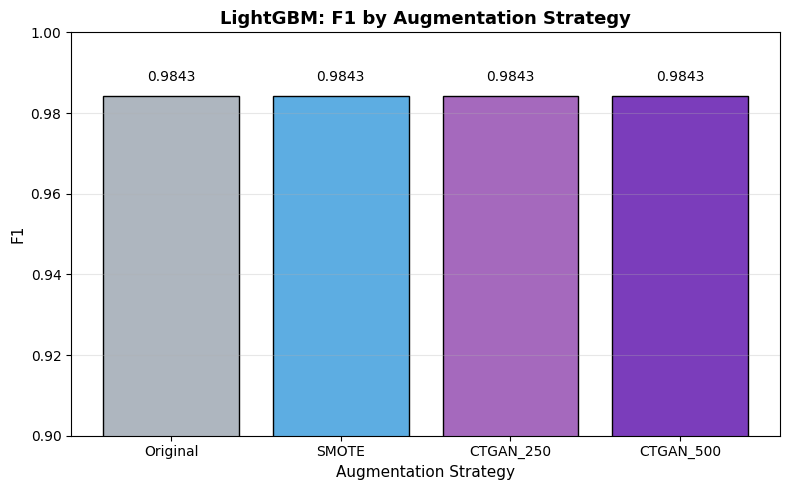

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_f1.png


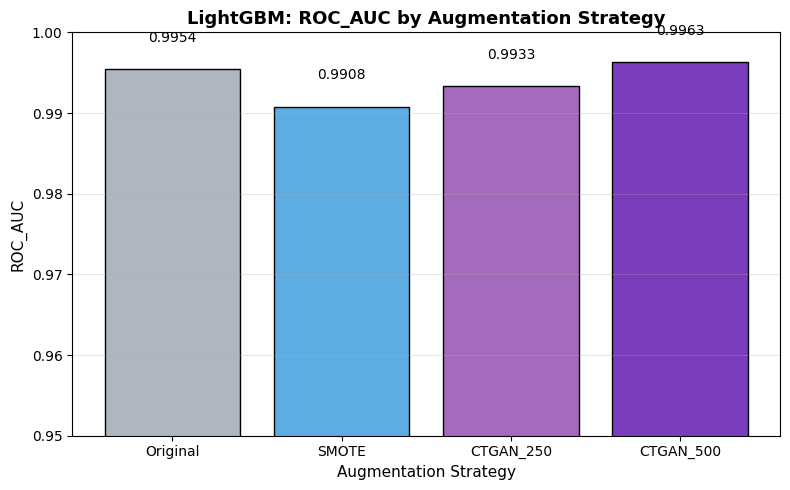

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_roc_auc.png


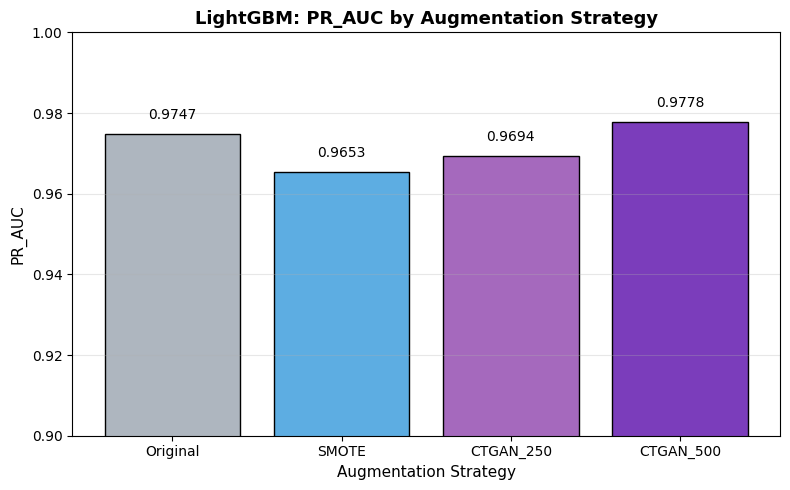

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_pr_auc.png


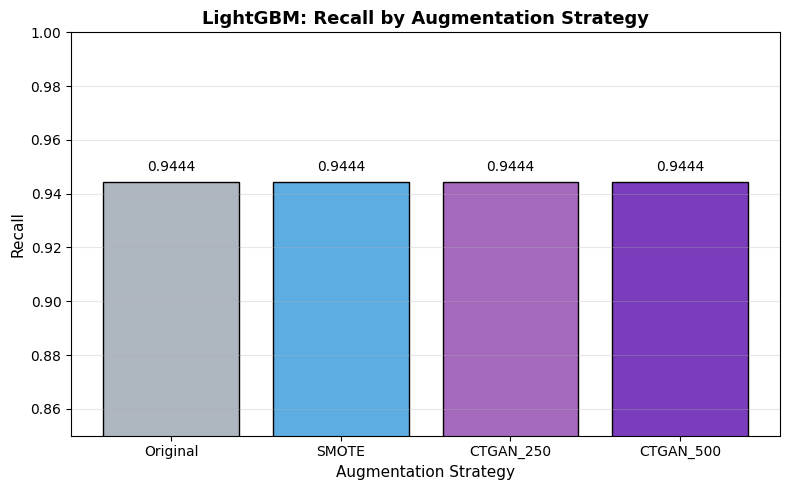

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_recall.png


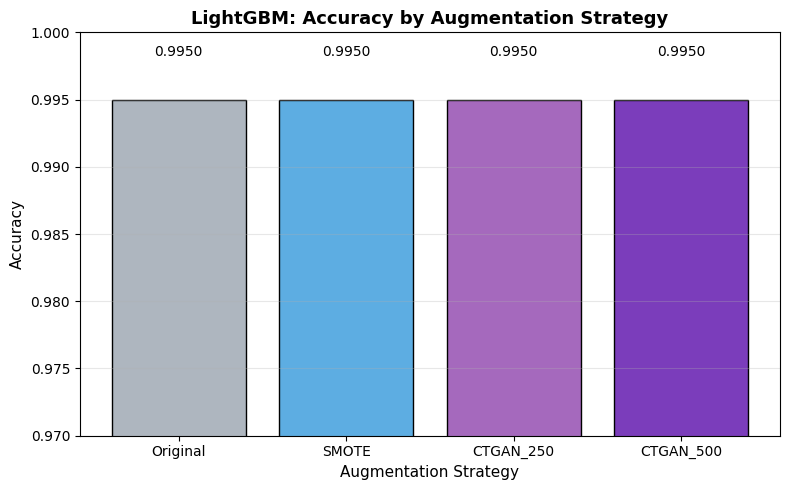

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_accuracy.png


In [ ]:
# ── Helper ────────────────────────────────────────────────────────────────
EXPERIMENTS = ["Original", "SMOTE", "CTGAN_250", "CTGAN_500"]
COLORS      = ["#AEB6BF", "#5DADE2", "#A569BD", "#7B3DBB"]

def bar_by_experiment(metric, model_name="LightGBM", ymin=None):
    data = all_results[all_results["Model"] == model_name].copy()
    data = data.set_index("Experiment").reindex(EXPERIMENTS)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(EXPERIMENTS, data[metric], color=COLORS, edgecolor="black")

    if ymin is not None:
        ax.set_ylim(ymin, 1.0)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f"{h:.4f}", ha="center", va="bottom", fontsize=10)

    ax.set_xlabel("Augmentation Strategy", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{model_name}: {metric} by Augmentation Strategy",
                 fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    fname = f"{FIGURE_DIR}/aug_{metric.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# Generate one chart per metric
bar_by_experiment("F1",      ymin=0.90)
bar_by_experiment("ROC_AUC", ymin=0.95)
bar_by_experiment("PR_AUC",  ymin=0.90)
bar_by_experiment("Recall",  ymin=0.85)
bar_by_experiment("Accuracy",ymin=0.97)

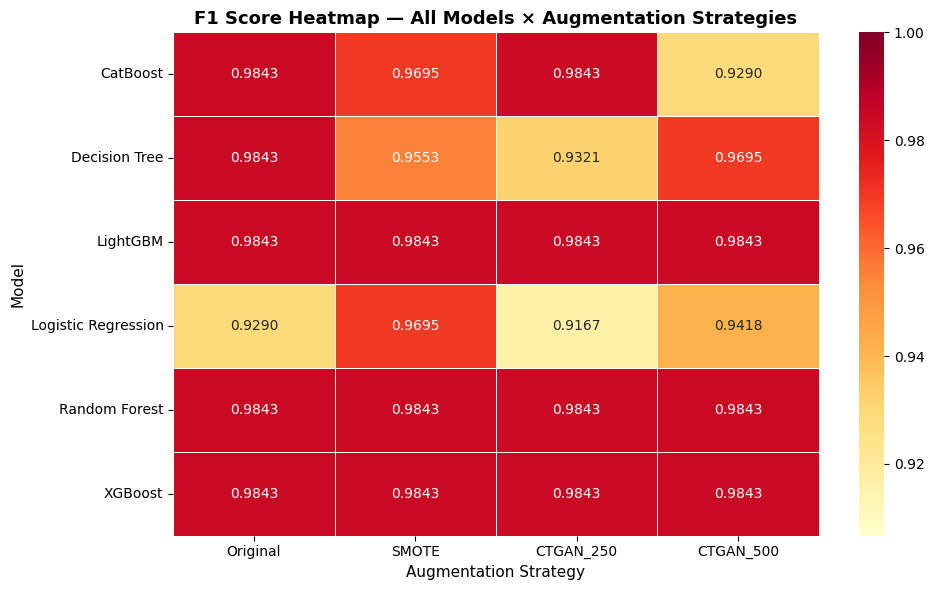

Saved: /content/drive/MyDrive/Ghana_Dropout_Project/figures/aug_heatmap_f1.png


In [ ]:
# Pivot on F1 for heatmap
pivot = all_results.pivot(index="Model", columns="Experiment", values="F1")
pivot = pivot.reindex(columns=EXPERIMENTS)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=pivot.min().min() - 0.01,
    vmax=1.0
)
ax.set_title("F1 Score Heatmap — All Models × Augmentation Strategies",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Augmentation Strategy", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.tight_layout()

fname = f"{FIGURE_DIR}/aug_heatmap_f1.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

In [ ]:
# Based on LightGBM F1 (primary model going into Notebook 6)
lgbm_comparison = all_results[all_results["Model"] == "LightGBM"].copy()
lgbm_comparison = lgbm_comparison.sort_values("PR_AUC", ascending=False)

best_experiment = lgbm_comparison.iloc[0]["Experiment"]
best_metrics    = lgbm_comparison.iloc[0]

print("=" * 55)
print("BEST AUGMENTATION STRATEGY FOR LightGBM")
print("=" * 55)
print(f"  Strategy:  {best_experiment}")
print(f"  F1:        {best_metrics['F1']:.4f}")
print(f"  ROC-AUC:   {best_metrics['ROC_AUC']:.4f}")
print(f"  PR-AUC:    {best_metrics['PR_AUC']:.4f}")
print(f"  Recall:    {best_metrics['Recall']:.4f}")

BEST AUGMENTATION STRATEGY FOR LightGBM
  Strategy:  CTGAN_500
  F1:        0.9843
  ROC-AUC:   0.9963
  PR-AUC:    0.9778
  Recall:    0.9444


In [ ]:
# Save the best augmented training set so Notebook 6 loads it directly

if best_experiment == "SMOTE":
    X_best = pd.DataFrame(X_train_smote, columns=X_train.columns)
    y_best = pd.Series(y_train_smote, name=TARGET)

elif best_experiment == "CTGAN_250":
    X_best = X_train_ctgan.copy()
    y_best = y_train_ctgan.copy()

elif best_experiment == "CTGAN_500":
    X_best = X_train_ctgan500.copy()
    y_best = y_train_ctgan500.copy()

else:   # Original
    X_best = X_train.copy()
    y_best = y_train.copy()

# Combine and save
best_train = X_best.copy()
best_train[TARGET] = y_best.values
best_train.to_csv(f"{DATA_DIR}/best_training_data.csv", index=False)

# Also save the untouched test set
test_set = X_test.copy()
test_set[TARGET] = y_test.values
test_set.to_csv(f"{DATA_DIR}/test_set.csv", index=False)

print(f"Best training data ({best_experiment}) saved → best_training_data.csv")
print(f"  Rows: {len(best_train)}")
print(f"  Dropout rate: {y_best.mean():.1%}")
print(f"\nTest set saved → test_set.csv")
print(f"  Rows: {len(test_set)}")

Best training data (CTGAN_500) saved → best_training_data.csv
  Rows: 1300
  Dropout rate: 44.2%

Test set saved → test_set.csv
  Rows: 200


In [ ]:
# Save the best LightGBM trained on the best augmented data
best_lgbm = LGBMClassifier(
    n_estimators=200, is_unbalance=True,
    learning_rate=0.05, num_leaves=63,
    random_state=42, verbosity=-1, n_jobs=-1
)
best_lgbm.fit(X_best, y_best)
joblib.dump(best_lgbm, f"{MODEL_DIR}/best_augmentation_model.pkl")

# Also save metadata about what was selected
metadata_out = {
    "best_experiment":   best_experiment,
    "training_rows":     int(len(X_best)),
    "dropout_rate":      float(round(y_best.mean(), 4)),
    "f1":                float(best_metrics["F1"]),
    "roc_auc":           float(best_metrics["ROC_AUC"]),
    "pr_auc":            float(best_metrics["PR_AUC"]),
}
with open(f"{MODEL_DIR}/best_augmentation_metadata.json", "w") as f:
    json.dump(metadata_out, f, indent=4)

print("Saved: best_augmentation_model.pkl")
print("Saved: best_augmentation_metadata.json")

Saved: best_augmentation_model.pkl
Saved: best_augmentation_metadata.json


In [ ]:
print("=" * 60)
print("NOTEBOOK 5 COMPLETE — CLASS IMBALANCE EXPERIMENTS")
print("=" * 60)
print()
print("Experiments run:")
print("  A. Original data (no augmentation)")
print("  B. SMOTE oversampling")
print("  C. CTGAN +250 synthetic dropout records")
print("  D. CTGAN +500 synthetic dropout records")
print()
print("Files saved:")
print("  data/best_training_data.csv")
print("  data/test_set.csv")
print("  results/original_results.csv")
print("  results/smote_results.csv")
print("  results/ctgan_results.csv")
print("  results/ctgan500_results.csv")
print("  results/augmentation_results.csv")
print("  results/lgbm_augmentation_comparison.csv")
print("  results/tstr_validation.csv")
print("  models/best_augmentation_model.pkl")
print("  models/ctgan_model.pkl")
print("  models/best_augmentation_metadata.json")
print()
print(f"Best augmentation strategy: {best_experiment}")
print(f"  F1:      {best_metrics['F1']:.4f}")
print(f"  ROC-AUC: {best_metrics['ROC_AUC']:.4f}")
print(f"  PR-AUC:  {best_metrics['PR_AUC']:.4f}")
print()
print("→ Notebook 6 will load best_training_data.csv and test_set.csv")
print("=" * 60)

NOTEBOOK 5 COMPLETE — CLASS IMBALANCE EXPERIMENTS

Experiments run:
  A. Original data (no augmentation)
  B. SMOTE oversampling
  C. CTGAN +250 synthetic dropout records
  D. CTGAN +500 synthetic dropout records

Files saved:
  data/best_training_data.csv
  data/test_set.csv
  results/original_results.csv
  results/smote_results.csv
  results/ctgan_results.csv
  results/ctgan500_results.csv
  results/augmentation_results.csv
  results/lgbm_augmentation_comparison.csv
  results/tstr_validation.csv
  models/best_augmentation_model.pkl
  models/ctgan_model.pkl
  models/best_augmentation_metadata.json

Best augmentation strategy: CTGAN_500
  F1:      0.9843
  ROC-AUC: 0.9963
  PR-AUC:  0.9778

→ Notebook 6 will load best_training_data.csv and test_set.csv
